# Surrogate-informed IBAnet fine-tuning (IBAnetV2)

Fine-tune an existing IBAnet with a **frozen LRN forward surrogate**. The objective
combines the original spike-and-slab NLL with spectrum reconstruction from the
predicted posterior mean. LRN weights stay fixed; gradients through LRN update
IBAnet. Export remains a standard three-output IBAnet package: LRN is needed
only during training.

Run `train_ibanet.ipynb` and `train_lrn_multilayer.ipynb` first. Install the
`training` and `plot` extras. Supply trusted **PyTorch checkpoints**, not just
ONNX ZIPs. The LRN checkpoint contains NumPy metadata and is loaded with
`weights_only=False`; do not load untrusted files. Edit the paths below before
running. This notebook does not launch either original training notebook.

In [1]:
from pathlib import Path
import sys, re, json, copy, math, hashlib
try:
    import tomllib
except ImportError:
    import tomli as tomllib
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'ibeamlab/ibanet.py').exists())
sys.path.insert(0, str(ROOT))
EXAMPLES = ROOT / 'examples'
import ibeamlab as ibl
from ibeamlab import IBAnet, IBAnetLoss, LRNModel, transforms
from ibeamlab._native import native

c:\Users\local_admin\.conda\envs\DL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and validate both models before loading data

Set checkpoint and configuration paths here. The model weights, architecture, and schema are checked before the expensive dataset load. Fine-tuning settings are in section 5.


In [2]:
DATASET_ROOT = EXAMPLES / 'datasets'
CONFIG_PATH = EXAMPLES / 'multilayer-generation.toml'
IBANET_CHECKPOINT = EXAMPLES / 'artifacts/ibanet_multilayer_compressed16/ibanet_state.pt'
LRN_CHECKPOINT = EXAMPLES / 'artifacts/new_lrn_rbs_10layers/lrn_state.pt'
# Both stored spectra and LRN targets must be pileup-free expected counts.
# For noisy datasets, switch off Poisson augmentation; the clean-target assumption then differs.
LRN_ARCHITECTURE = dict(hidden_size=256, contribution_size=512,
    setup_embedding_dim=32, layer_embedding_dim=256, block_hidden_sizes=(768, 768),
    decoder_hidden_sizes=(768, 768), refiner_hidden_channels=32, refiner_kernel_size=8)
SEED = 7
for path in (IBANET_CHECKPOINT, LRN_CHECKPOINT):
    if not path.is_file(): raise FileNotFoundError(f'Choose a trained PyTorch checkpoint: {path}')
base_checkpoint = torch.load(IBANET_CHECKPOINT, map_location='cpu', weights_only=True)
lrn_checkpoint = torch.load(LRN_CHECKPOINT, map_location='cpu', weights_only=False)
base_signature = base_checkpoint['signature']
MAX_LAYERS = base_signature['max_layers']
TARGET_SCALE = base_signature['target_scale']
POISSON_NOISE = base_signature.get('input_noise', {}).get('poisson', False)
METHOD = lrn_checkpoint['method']
LRN_OUTPUT_SCALE = float(lrn_checkpoint['output_scale'])
if not np.isfinite(LRN_OUTPUT_SCALE) or LRN_OUTPUT_SCALE <= 0: raise ValueError('Invalid LRN output scale')


In [3]:
configuration = ibl.load_generation_configuration(CONFIG_PATH)
if configuration.variations:
    raise ValueError("IBAnet requires fixed beam/detector settings; choose a config without setup variations")
if not 1 <= MAX_LAYERS <= configuration.maximum_layers:
    raise ValueError("MAX_LAYERS exceeds the configuration")
study = configuration.study(MAX_LAYERS)
ELEMENTS = tuple(configuration.elements)
LABELS = tuple(d.label for d in study.experiment.detectors)
LAYER_DATASETS = {}
for path in sorted(DATASET_ROOT.rglob("layers_*")):
    match = re.fullmatch(r"layers_(\d+)", path.name)
    if path.is_dir() and match and 1 <= int(match.group(1)) <= MAX_LAYERS:
        LAYER_DATASETS.setdefault(int(match.group(1)), []).append(path)
if not LAYER_DATASETS:
    raise FileNotFoundError(f"No layers_XX datasets under {DATASET_ROOT}")
print("Detector order:", LABELS)
print("Element order:", ELEMENTS)
print("Maximum layers:", MAX_LAYERS)
if CONFIG_PATH.read_text(encoding='utf-8') != base_signature['config_text']:
    raise ValueError('Use the original IBAnet generation configuration')
if list(ELEMENTS) != base_signature['elements'] or list(LABELS) != base_signature['labels']:
    raise ValueError('IBAnet element/detector layout differs')
if lrn_checkpoint['max_layers'] != MAX_LAYERS or METHOD not in LABELS:
    raise ValueError('LRN method/layer count differs')
if tuple(lrn_checkpoint['input_parameter_names']) != tuple(study.parameter_names):
    raise ValueError('LRN physical parameter order differs')
if lrn_checkpoint.get('layer_representation') != 'thickness_and_concentrations':
    raise ValueError('Use an LRN trained on thickness and concentrations')
if len(LABELS) != 1:
    raise ValueError('This first notebook supports the single-detector LRN notebook schema')
actual_datasets = [str(p.resolve()) for paths in LAYER_DATASETS.values() for p in paths]
if actual_datasets != base_signature['datasets']:
    raise ValueError('Dataset collection/order differs from IBAnet checkpoint')

Detector order: ('RBS',)
Element order: ('Li', 'Ni', 'Mn', 'Co', 'O', 'C', 'F', 'P', 'Cu', 'Al')
Maximum layers: 10


In [4]:
SPECTRUM_LENGTHS = dict(base_signature['spectrum_lengths'])
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IBAnet(study, SPECTRUM_LENGTHS, elements=ELEMENTS,
    **base_signature['architecture']).to(device)
model.load_state_dict(base_checkpoint['model_state_dict'])
lrn_width = lrn_checkpoint['model_state_dict']['output_scale'].numel()
if lrn_width != SPECTRUM_LENGTHS[METHOD]: raise ValueError('LRN channel width differs')
lrn = LRNModel(study, {METHOD: lrn_width}, **LRN_ARCHITECTURE).to(device)
lrn.load_state_dict(lrn_checkpoint['model_state_dict'])
lrn.eval().requires_grad_(False)
nll_loss = IBAnetLoss()
print('Models loaded on:', device)


Models loaded on: cuda


In [5]:
class EdpToLRN(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('minimum', torch.as_tensor(lrn_checkpoint['input_minimum'], dtype=torch.float32))
        self.register_buffer('scale', torch.as_tensor(lrn_checkpoint['input_scale'], dtype=torch.float32))
        if self.minimum.shape != (len(study.parameters),) or self.scale.shape != self.minimum.shape:
            raise ValueError('Invalid LRN input scaler shape')
        if not torch.isfinite(self.minimum).all() or not torch.isfinite(self.scale).all() or (self.scale <= 0).any():
            raise ValueError('Invalid LRN input scaling')
        self.features = []
        for parameter in study.parameters:
            if parameter.kind == 'layer_thickness': self.features.append((parameter.layer, None))
            elif parameter.kind == 'concentration': self.features.append((parameter.layer, ELEMENTS.index(parameter.element)))
            else: raise ValueError('Only fixed-setup thickness/composition LRNs are supported')
        for layer in range(MAX_LAYERS):
            names = {p.element for p in study.parameters if p.layer == layer and p.kind == 'concentration'}
            if names != set(ELEMENTS): raise ValueError('LRN needs all elemental concentration features per layer')
    def physical_parameters(self, densities):
        thickness = densities.sum(dim=-1)
        fractions = densities / thickness.clamp_min(1e-12).unsqueeze(-1)
        return torch.stack([thickness[:, layer] if element is None else fractions[:, layer, element]
                            for layer, element in self.features], dim=1)
    def forward(self, densities):
        return (self.physical_parameters(densities) - self.minimum) / self.scale
adapter = EdpToLRN().to(device)
reference_transform = transforms.build_lrn_input_transform(study)
scaler = reference_transform.transforms[-1]
np.testing.assert_allclose(adapter.minimum.cpu().numpy(), scaler.minimum, rtol=1e-5, atol=1e-6)
np.testing.assert_allclose(adapter.scale.cpu().numpy(), scaler.scale, rtol=1e-5, atol=1e-6)

# Catch incompatible forward/input schemas before any dataset is read.
model.eval()
with torch.no_grad():
    smoke_prediction = model(torch.ones(2, sum(SPECTRUM_LENGTHS.values()), device=device))
    smoke_spectrum = lrn(adapter(smoke_prediction.mean / TARGET_SCALE))
    if smoke_spectrum.shape != (2, lrn_width) or not torch.isfinite(smoke_spectrum).all():
        raise ValueError('Invalid loaded model forward pass')
print('Both model forward passes and saved LRN scaling checked before data loading')


Both model forward passes and saved LRN scaling checked before data loading


## 2. Load data and restore the saved split

Models are already loaded. Reuse saved split indices and normalization buffers; no new normalization is fitted. Keep the original dataset collection and ordering. If a model checkpoint or architecture needs correction, rerun the loading cells without reloading these arrays.


In [6]:
def template_table(text):
    value = tomllib.loads(text)
    value.pop("format", None)
    value.pop("format_version", None)
    return value

def load_case(dataset_path, layer_count):
    dataset = ibl.open_dataset(dataset_path)
    if not dataset.metadata.complete or not len(dataset):
        raise ValueError(f"Incomplete or empty dataset: {dataset_path}")
    case = configuration.study(layer_count)
    config = case._config()
    provenance = tomllib.loads(dataset._reader.metadata.generation_config_toml)
    expected_setup = template_table(native.sample.setup_to_toml(config.setup))
    expected_sample = template_table(native.sample.sample_to_toml(config.sample))
    if provenance.get("setup") != expected_setup or provenance.get("sample") != expected_sample:
        raise ValueError(f"Dataset template/setup differs from CONFIG_PATH: {dataset_path}")
    expected_methods = [{"label": m.label, "iba_method": m.iba_method,
                         "reference_file": Path(m.reference_file).as_posix()} for m in config.methods]
    if provenance.get("methods") != expected_methods:
        raise ValueError(f"Dataset method/reference differs from CONFIG_PATH: {dataset_path}")
    names = tuple(dataset.metadata.parameter_names)
    if len(set(names)) != len(names) or set(names) != set(case.parameter_names):
        raise ValueError(f"Parameter names do not match the case study: {dataset_path}")
    stored_targets = {p["name"]: p["target"] for p in provenance.get("parameters", [])}
    for p in case.parameters:
        expected_target = ({"type": "layer_thickness", "layer": p.layer} if p.kind == "layer_thickness"
                           else {"type": "species_concentration", "layer": p.layer, "element": p.element})
        if stored_targets.get(p.name) != expected_target:
            raise ValueError(f"Parameter target differs for {p.name}: {dataset_path}")
    rows = np.asarray(dataset.parameters, dtype=np.float32)
    columns = {name: i for i, name in enumerate(names)}
    densities = np.zeros((len(rows), MAX_LAYERS, len(ELEMENTS)), np.float32)
    for layer_index in range(layer_count):
        layer = case.experiment.sample.layers[layer_index]
        thickness = np.full(len(rows), layer.thickness, np.float32)
        fractions = np.tile([next(s.concentration for s in layer.species if s.element == element)
                             for element in ELEMENTS], (len(rows), 1)).astype(np.float32)
        for p in case.parameters:
            if p.layer != layer_index:
                continue
            if p.kind == "layer_thickness":
                thickness = rows[:, columns[p.name]]
            elif p.kind == "concentration":
                fractions[:, ELEMENTS.index(p.element)] = rows[:, columns[p.name]]
        if np.any(thickness < 0) or np.any(fractions < 0) or not np.allclose(fractions.sum(1), 1, atol=1e-6, rtol=0):
            raise ValueError(f"Invalid thickness/composition: {dataset_path}")
        densities[:, layer_index] = thickness[:, None] * fractions
    spectra = {label: np.asarray(dataset.spectra(label), dtype=np.float32) for label in LABELS}
    if any(not np.isfinite(x).all() or np.any(x < 0) for x in spectra.values()) or not np.isfinite(densities).all():
        raise ValueError(f"Nonfinite or negative training data: {dataset_path}")
    return spectra, densities

loaded = []
SPECTRUM_LENGTHS = {label: 0 for label in LABELS}
for layer_count, paths in sorted(LAYER_DATASETS.items()):
    for path in paths:
        spectra, densities = load_case(path, layer_count)
        for label in LABELS:
            SPECTRUM_LENGTHS[label] = max(SPECTRUM_LENGTHS[label], spectra[label].shape[1])
        loaded.append((spectra, densities))
        print(f"Loaded {path}: {len(densities):,} samples, {layer_count} layers")
x_parts, a_parts = [], []
for spectra, densities in loaded:
    x_parts.append(np.concatenate([
        np.pad(spectra[label], ((0, 0), (0, SPECTRUM_LENGTHS[label] - spectra[label].shape[1])))
        for label in LABELS], axis=1))
    a_parts.append(densities)
x_raw = np.concatenate(x_parts)
a_raw = np.concatenate(a_parts)
del loaded, x_parts, a_parts
print("Raw spectra:", x_raw.shape, "EDP:", a_raw.shape)

Loaded d:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_01: 200,000 samples, 1 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_01: 200,000 samples, 1 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_01: 200,000 samples, 1 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_02: 100,000 samples, 2 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_02: 100,000 samples, 2 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_02: 100,000 samples, 2 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_03: 100,000 samples, 3 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_03: 100,000 samples, 3 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_03: 100,000 samples, 3 layers
Loaded d:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_04: 100,000 samples, 4 layers
Loaded d:\ibeamlab\e

In [7]:
if SPECTRUM_LENGTHS != base_signature['spectrum_lengths']:
    raise ValueError('Spectrum channel lengths differ from checkpoint')
train_indices, val_indices, test_indices = (
    base_checkpoint[k].numpy() for k in ('train_indices', 'val_indices', 'test_indices'))
indices = np.concatenate((train_indices, val_indices, test_indices))
if len(indices) != len(x_raw) or not np.array_equal(np.sort(indices), np.arange(len(x_raw))):
    raise ValueError('Saved split does not partition current data')
noise_policy = base_signature.get('input_noise', {})
def fixed_poisson(expected, seed):
    generator = torch.Generator().manual_seed(seed)
    result = np.empty_like(expected)
    for start in range(0, len(expected), 512):
        result[start:start+512] = torch.poisson(torch.from_numpy(expected[start:start+512]), generator=generator).numpy()
    return result
x_train = x_raw[train_indices]
x_val_clean, x_test_clean = x_raw[val_indices], x_raw[test_indices]
x_val = fixed_poisson(x_val_clean, noise_policy.get('validation_seed', SEED+1)) if POISSON_NOISE else x_val_clean
x_test = fixed_poisson(x_test_clean, noise_policy.get('test_seed', SEED+2)) if POISSON_NOISE else x_test_clean
a_train, a_val, a_test = (a_raw[i] * TARGET_SCALE for i in (train_indices, val_indices, test_indices))
print('Train/validation/test:', len(x_train), len(x_val), len(x_test))


Train/validation/test: 2770000 20000 10000


## 3. Differentiable EDP-to-LRN adapter

Convert physical posterior mean densities to thickness and composition, then
apply the saved LRN parameter scaling in Torch. Do not call native/NumPy
transforms or `lrn.predict()` on the training path: those break autograd.
Exactly empty layers remain zero when the original scaler maps padding to zero.
Tiny positive predicted layers remain active; no hard presence/thickness mask is
introduced. This preserves the surrogate's existing behavior but is a limitation
when padded predictions contain small nonzero means. Never use true layer counts
to mask predicted layers, since those counts are unavailable at inference.

The reconstruction is `LRN(E[A])`, not `E[LRN(A)]`; this is a mean-profile
regularizer, not a full probabilistic observation likelihood.

In [8]:
# Verify saved scaling against the native transform on real, including padded, profiles.
probe = torch.from_numpy(a_raw[:min(32, len(a_raw))]).to(device)
physical = adapter.physical_parameters(probe).detach().cpu().numpy()
np.testing.assert_allclose(adapter(probe).detach().cpu().numpy(), reference_transform.apply(physical), rtol=1e-5, atol=1e-6)
# Use a count-space chi-square-style penalty. Normalize once by the measured
# baseline validation value so SPECTRUM_WEIGHT has an interpretable starting scale.
def spectrum_loss(reconstructed, target):
    return ((reconstructed - target).square() / (target + 1.0)).mean()
def reconstruct(prediction):
    return lrn(adapter(prediction.mean / TARGET_SCALE)) / LRN_OUTPUT_SCALE
# Explicitly verify the frozen LRN preserves gradients to its inputs.
probe = probe.detach().requires_grad_(True)
lrn(adapter(probe)).sum().backward()
assert probe.grad is not None and torch.isfinite(probe.grad).all() and probe.grad.abs().sum() > 0
assert all(p.grad is None for p in lrn.parameters())
print('Native/Torch preprocessing parity and frozen-surrogate gradient flow verified')

Native/Torch preprocessing parity and frozen-surrogate gradient flow verified


## 4. Baseline diagnostics and fixed checkpoint-selection objective

Compare reconstruction from true EDPs with reconstruction from IBAnet means. The former measures the forward surrogate error floor. Losses use clean expected spectra; only inverse inputs receive counting noise. Select checkpoints with the **fixed final** spectrum weight, even while the training weight ramps, so scores remain comparable across epochs. Report NLL, physical EDP MAE, presence Brier score, and raw reconstruction loss separately.

In [12]:
@torch.no_grad()
def evaluate(inputs, targets, clean, batch_size=2048):
    model.eval(); lrn.eval()
    totals = dict(nll=0.0, spectrum=0.0, edp_mae=0.0, presence_brier=0.0)
    for start in range(0, len(inputs), batch_size):
        x = torch.from_numpy(inputs[start:start+batch_size]).to(device)
        a = torch.from_numpy(targets[start:start+batch_size]).to(device)
        expected = torch.from_numpy(clean[start:start+batch_size]).to(device)
        prediction = model(x)
        metrics = dict(nll=nll_loss(prediction, a), spectrum=spectrum_loss(reconstruct(prediction), expected),
            edp_mae=(prediction.mean-a).abs().mean()/TARGET_SCALE,
            presence_brier=(prediction.P-(a>0).float()).square().mean())
        for name, value in metrics.items(): totals[name] += float(value)*len(x)
    return {name: value/len(inputs) for name, value in totals.items()}
baseline_validation = evaluate(x_val, a_val, x_val_clean)
baseline_test = evaluate(x_test, a_test, x_test_clean)
with torch.no_grad():
    floor_total = 0.0
    for start in range(0, len(a_val), 2048):
        a = torch.from_numpy(a_val[start:start+2048]).to(device) / TARGET_SCALE
        clean = torch.from_numpy(x_val_clean[start:start+2048]).to(device)
        floor_total += float(spectrum_loss(lrn(adapter(a))/LRN_OUTPUT_SCALE, clean))*len(a)
    surrogate_floor = floor_total / len(a_val)
# Replaced after the pre-fine-tuning diagnostics below; do not normalize by
# the contaminated IBAnet-mean baseline.
def selection_score(metrics):
    return metrics['nll'] + SPECTRUM_WEIGHT * metrics['spectrum']/SPECTRUM_NORMALIZER
print('Baseline validation:', baseline_validation)
print('LRN reconstruction loss from true profiles:', surrogate_floor)
print('Baseline test:', baseline_test)
if surrogate_floor > baseline_validation['spectrum']:
    print('Inspect surrogate fidelity: true profiles reconstruct worse than inverse means.')

Baseline validation: {'nll': -106.38949504394532, 'spectrum': 1043795848.0384, 'edp_mae': 610.38432421875, 'presence_brier': 0.06150021207332611}
LRN reconstruction loss from true profiles: 2.821303797149658
Baseline test: {'nll': -106.12407449951172, 'spectrum': 535198208.2048, 'edp_mae': 609.6576241210937, 'presence_brier': 0.061532759577035905}


Per-sample spectrum loss quantiles: {'median': np.float64(162.64180755615234), 'p95': np.float64(12460.19785156249), 'p99': np.float64(279493.7924999999), 'max': np.float64(2202941784064.0)}
Worst validation rows and losses: [(5709, 2202941784064.0), (9459, 1709380206592.0), (17644, 1049437011968.0), (1915, 1040328949760.0), (11612, 1036784566272.0)]
True layer thickness quantiles: [[2.71596640e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [5.76591992e+03 3.70309265e+03 3.23820630e+03 1.93601312e+03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [3.89916309e+04 3.50540078e+04 4.10121096e+04 4.77518451e+04
  5.20650578e+04 5.15120834e+04 5.65233996e+04 6.36709973e+04
  6.24110279e+04 2.94466718e+04]
 [4.74890579e+04 5.32141486e+04 6.49424911e+04 7.73256166e+04
  8.87440792e+04 9.43623955e+04 1.10153883e+05 1.19607053e+05
  1.36948882e+05 1.4

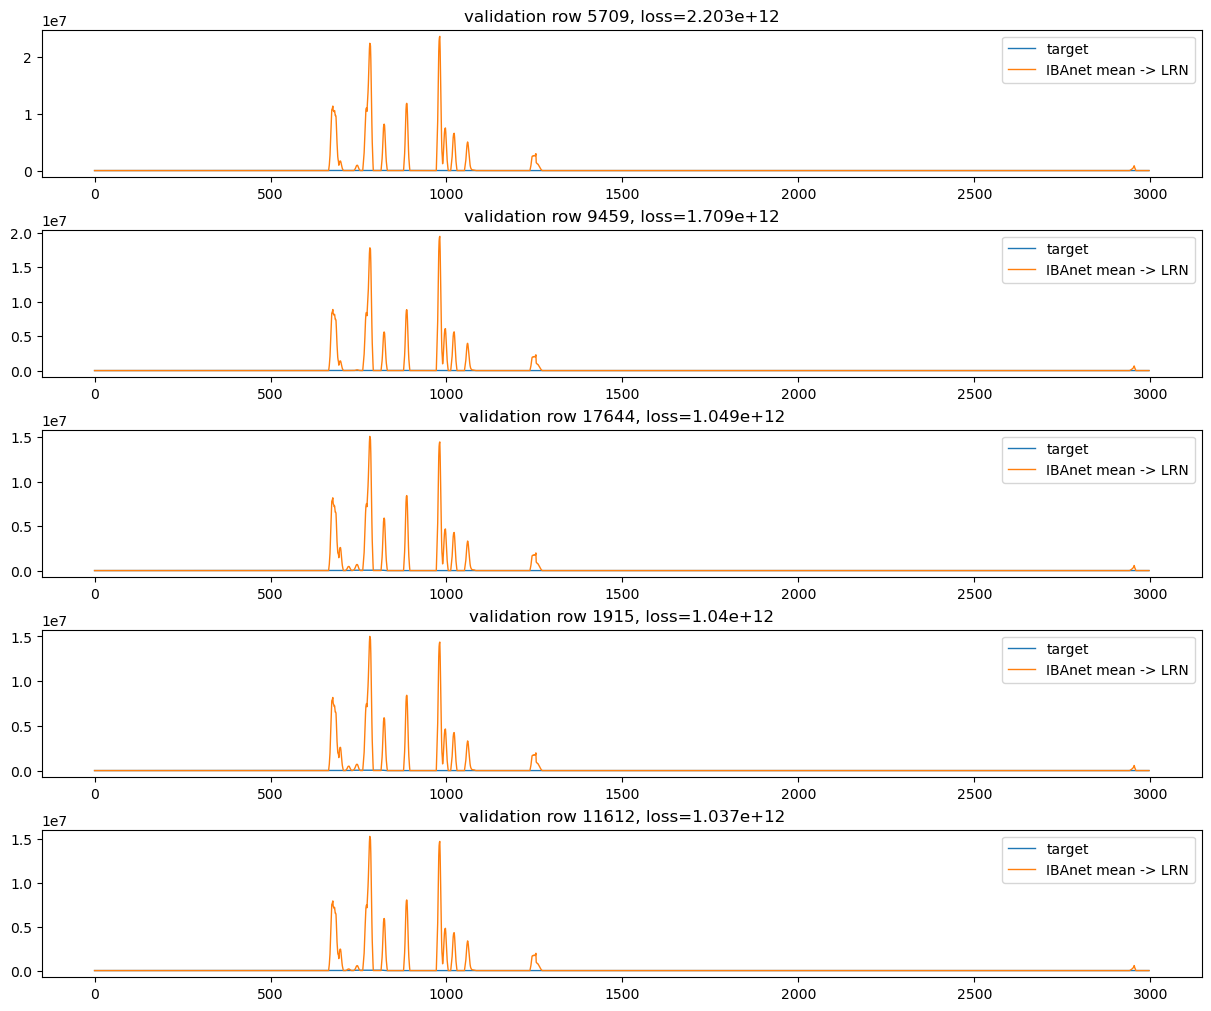

True-profile per-sample loss quantiles: {'median': np.float64(1.9572912454605103), 'p95': np.float64(7.083859705924987), 'p99': np.float64(13.984487991332962), 'max': np.float64(341.4564208984375)}
Selected reconstruction normalizer: 7.083859920501709


In [13]:
# Diagnose profile-domain violations before enabling fine-tuning.
@torch.no_grad()
def _diagnostic_batches(batch_size=2048):
    losses, predicted, targets = [], [], []
    for start in range(0, len(x_val), batch_size):
        stop = min(start + batch_size, len(x_val))
        x = torch.from_numpy(x_val[start:stop]).to(device)
        prediction = model(x)
        mean = prediction.mean / TARGET_SCALE
        expected = torch.from_numpy(x_val_clean[start:stop]).to(device)
        output = lrn(adapter(mean)) / LRN_OUTPUT_SCALE
        losses.append(((output - expected).square() / (expected + 1.0)).mean(dim=1).cpu())
        predicted.append(mean.cpu()); targets.append(torch.from_numpy(a_val[start:stop].copy() / TARGET_SCALE))
    return (torch.cat(losses).numpy(), torch.cat(predicted).numpy(), torch.cat(targets).numpy())
sample_loss, predicted_density, true_density = _diagnostic_batches()
print('Per-sample spectrum loss quantiles:', dict(zip(('median','p95','p99','max'), np.quantile(sample_loss, (0.5, 0.95, 0.99, 1.0)))))
worst = np.argsort(sample_loss)[-5:][::-1]
print('Worst validation rows and losses:', [(int(i), float(sample_loss[i])) for i in worst])

def _profile_summary(name, density):
    thickness = density.sum(axis=2)
    total = thickness.sum(axis=1)
    active = thickness > 0
    print(name, 'layer thickness quantiles:', np.quantile(thickness, (0, .5, .95, .99, 1), axis=0))
    print(name, 'total thickness quantiles:', np.quantile(total, (0, .5, .95, .99, 1)))
    print(name, 'near-empty layer fractions (<1e-3):', (thickness < 1e-3).mean(axis=0))
    return thickness
true_thickness = _profile_summary('True', true_density)
predicted_thickness = _profile_summary('IBAnet mean', predicted_density)

# Compare predicted physical features with the LRN scaler's training interval.
predicted_features = adapter.physical_parameters(torch.from_numpy(predicted_density).to(device)).cpu().numpy()
feature_low = adapter.minimum.cpu().numpy()
feature_high = feature_low + adapter.scale.cpu().numpy()
outside = (predicted_features < feature_low) | (predicted_features > feature_high)
print(f'Predicted physical features outside saved LRN scaler interval: {outside.mean():.3%} ({outside.any(axis=1).mean():.3%} of samples)')
print('Maximum normalized feature excursion:', np.max(np.abs((predicted_features - feature_low) / adapter.scale.cpu().numpy()), axis=0))

# Diagnostic only: zero layers below several thickness cutoffs before LRN evaluation.
def _zero_small_layers(density, cutoff):
    value = torch.from_numpy(density).to(device)
    thickness = value.sum(dim=-1, keepdim=True)
    return torch.where(thickness < cutoff, torch.zeros_like(value), value)
cutoffs = (0.0, 1e-6, 1e-4, 1e-2, 1e-1)
padding_results = {}
for cutoff in cutoffs:
    subtotal = 0.0
    for start in range(0, len(predicted_density), 2048):
        stop = min(start + 2048, len(predicted_density))
        padded = lrn(adapter(_zero_small_layers(predicted_density[start:stop], cutoff))) / LRN_OUTPUT_SCALE
        target = torch.from_numpy(x_val_clean[start:stop]).to(device)
        subtotal += float(spectrum_loss(padded, target)) * (stop - start)
    value = subtotal / len(predicted_density)
    padding_results[cutoff] = value
print('Small-layer zeroing diagnostic:', padding_results)

# Show the worst reconstructed spectra for visual inspection.
with torch.no_grad():
    worst_spectra = []
    for index in worst:
        worst_spectra.append(reconstruct(model(torch.from_numpy(x_val[index:index+1]).to(device))).cpu().numpy()[0])
clean_spectra = x_val_clean[worst]
fig, axes = plt.subplots(len(worst), 1, figsize=(12, 2 * len(worst)), squeeze=False, constrained_layout=True)
for position, (axis, index) in enumerate(zip(axes[:, 0], worst)):
    axis.plot(clean_spectra[position], label='target', linewidth=1)
    axis.plot(worst_spectra[position], label='IBAnet mean -> LRN', linewidth=1)
    axis.set_title(f'validation row {index}, loss={sample_loss[index]:.4g}')
    axis.legend()
plt.show()

# Use the true-profile p95 as a stable scale; never let the bad IBAnet baseline
# define the reconstruction term. The raw loss remains reported separately.
with torch.no_grad():
    true_profile_loss = []
    for start in range(0, len(true_density), 2048):
        stop = min(start + 2048, len(true_density))
        output = lrn(adapter(torch.from_numpy(true_density[start:stop]).to(device))) / LRN_OUTPUT_SCALE
        target = torch.from_numpy(x_val_clean[start:stop]).to(device)
        true_profile_loss.append(((output - target).square() / (target + 1.0)).mean(dim=1).cpu())
true_profile_loss = torch.cat(true_profile_loss).numpy()
print('True-profile per-sample loss quantiles:', dict(zip(('median','p95','p99','max'), np.quantile(true_profile_loss, (0.5, 0.95, 0.99, 1.0)))))
SPECTRUM_NORMALIZER = max(float(np.quantile(true_profile_loss, 0.95)), 1e-8)
print('Selected reconstruction normalizer:', SPECTRUM_NORMALIZER)

## 5. Fine-tuning settings, training, and best-checkpoint restore

Edit the settings at the top of the following training cell. Validation defaults to batches of 2048; reduce the training batch size if GPU memory is insufficient. Existing output folders are safe to reuse. A compatible saved best checkpoint is loaded on rerun with a fresh optimizer; the schedule restarts. Interruption restores the best completed validation checkpoint. Source checkpoints are never overwritten.


In [ ]:
OUTPUT_DIR = EXAMPLES / 'artifacts/ibanetv2_surrogate'
BATCH_SIZE = 256
VALIDATION_BATCH_SIZE = 2048
EPOCHS = 20
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0
SPECTRUM_WEIGHT = 0.1  # Inspect baseline loss/gradient magnitudes before increasing.
RAMP_EPOCHS = 5
if EPOCHS < 1 or RAMP_EPOCHS < 1 or not math.isfinite(SPECTRUM_WEIGHT) or SPECTRUM_WEIGHT < 0:
    raise ValueError('Invalid epochs or reconstruction weight')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
weights_path = OUTPUT_DIR / 'ibanetv2_state.pt'
def file_hash(path): return hashlib.sha256(path.read_bytes()).hexdigest()
signature = dict(base_signature=base_signature, iban_hash=file_hash(IBANET_CHECKPOINT),
    lrn_hash=file_hash(LRN_CHECKPOINT), lrn_architecture=LRN_ARCHITECTURE,
    spectrum_weight=SPECTRUM_WEIGHT, spectrum_normalizer=SPECTRUM_NORMALIZER,
    reconstruction_loss='count_chi2_mean', ramp_epochs=RAMP_EPOCHS, seed=SEED)
history = []
best_state = copy.deepcopy({k:v.cpu() for k,v in model.state_dict().items()})
best_score = selection_score(baseline_validation)
if weights_path.exists():
    previous = torch.load(weights_path, map_location='cpu', weights_only=True)
    if previous['finetuning_signature'] != signature: raise ValueError('Fine-tuning checkpoint settings differ; choose another OUTPUT_DIR')
    model.load_state_dict(previous['model_state_dict'])
    history = previous['history']
    best_state = copy.deepcopy(previous['model_state_dict'])
    best_score = selection_score(evaluate(x_val, a_val, x_val_clean, batch_size=VALIDATION_BATCH_SIZE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(a_train)),
    batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
noise_generator = torch.Generator(device=device).manual_seed(SEED+3)
def save_best():
    record = dict(model_state_dict=best_state, signature=base_signature, finetuning_signature=signature,
        train_indices=base_checkpoint['train_indices'], val_indices=base_checkpoint['val_indices'],
        test_indices=base_checkpoint['test_indices'], history=history, best_validation_score=best_score,
        baseline_validation=baseline_validation, baseline_test=baseline_test, surrogate_floor=surrogate_floor)
    temporary = weights_path.with_suffix('.pt.tmp')
    torch.save(record, temporary); temporary.replace(weights_path)
save_best()
try:
    for epoch in tqdm(range(EPOCHS), desc='Surrogate-informed epochs'):
        weight = SPECTRUM_WEIGHT * min(1.0, epoch/RAMP_EPOCHS)
        model.train(); lrn.eval()
        train_total = 0.0; seen = 0
        for clean, target in loader:
            clean, target = clean.to(device), target.to(device)
            inputs = torch.poisson(clean, generator=noise_generator) if POISSON_NOISE else clean
            optimizer.zero_grad(set_to_none=True)
            prediction = model(inputs)
            loss = nll_loss(prediction, target)
            if weight > 0:
                loss = loss + weight * spectrum_loss(reconstruct(prediction), clean)/SPECTRUM_NORMALIZER
            if not torch.isfinite(loss): raise FloatingPointError('Nonfinite fine-tuning loss')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM, error_if_nonfinite=True)
            optimizer.step()
            train_total += float(loss.detach())*len(inputs); seen += len(inputs)
        metrics = evaluate(x_val, a_val, x_val_clean, batch_size=VALIDATION_BATCH_SIZE)
        score = selection_score(metrics)
        if not math.isfinite(score): raise FloatingPointError('Nonfinite validation score')
        history.append(dict(epoch=len(history)+1, weight=weight, train_loss=train_total/seen, score=score, **metrics))
        if score < best_score:
            best_score = score
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        save_best()
        print(history[-1])
except KeyboardInterrupt:
    print('Interrupted; restoring the best completed checkpoint')
finally:
    model.load_state_dict(best_state)
    model.eval()
print('Best fixed-weight validation score:', best_score)

## 6. Compare held-out performance and export

A better combined score need not mean lower EDP error. Compare the separate held-out metrics before deploying. Export contains only the fine-tuned IBAnet, with mean, presence probability, and full posterior std; there is no inference-time LRN cost.

In [ ]:
finetuned_test = evaluate(x_test, a_test, x_test_clean)
for name in baseline_test:
    print(f'{name}: baseline={baseline_test[name]:.6g}, fine-tuned={finetuned_test[name]:.6g}')
if history:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3), constrained_layout=True)
    for ax, key in zip(axes, ('nll', 'spectrum', 'edp_mae')):
        ax.plot([r['epoch'] for r in history], [r[key] for r in history])
        ax.axhline(baseline_validation[key], linestyle='--', label='baseline')
        ax.set(xlabel='Epoch', ylabel=key); ax.legend()
    plt.show()
report = dict(baseline_validation=baseline_validation, baseline_test=baseline_test,
    finetuned_validation=evaluate(x_val, a_val, x_val_clean), finetuned_test=finetuned_test,
    surrogate_floor=surrogate_floor, spectrum_normalizer=SPECTRUM_NORMALIZER,
    spectrum_weight=SPECTRUM_WEIGHT, iban_checkpoint_sha256=file_hash(IBANET_CHECKPOINT),
    lrn_checkpoint_sha256=file_hash(LRN_CHECKPOINT))
(OUTPUT_DIR / 'finetuning_metrics.json').write_text(json.dumps(report, indent=2), encoding='utf-8')


In [ ]:
package_path = OUTPUT_DIR / f"ibanetv2_{MAX_LAYERS}layers.zip"
export_suffix = 1
while package_path.exists():
    # A previous export may exist even if its parity check was interrupted.
    package_path = OUTPUT_DIR / f"ibanetv2_{MAX_LAYERS}layers_{export_suffix:03d}.zip"
    export_suffix += 1
# Verify against the same current CPU/eval weights used for ONNX export.
# `estimate` from section 5 may be stale or computed with CUDA kernels.
export_model = copy.deepcopy(model).cpu().eval()
check_count = min(8, len(x_test))
check_inputs = np.array(x_test[:check_count], dtype=np.float32, copy=True)
with torch.inference_mode():
    export_reference = torch.cat([
        export_model(torch.from_numpy(row[None])).mean
        for row in check_inputs], dim=0).numpy() / TARGET_SCALE
export_model.export(package_path, output_inverse_factor=TARGET_SCALE, need_pileup_subtraction=True,
             pileup_fudge_factor_seconds=0.4e-6)
metadata = native.model.ModelPackage.open(package_path).metadata
assert metadata.format_version == 4
assert metadata.class_name == "IBAnet"
assert metadata.inverse.need_pileup_subtraction
np.testing.assert_allclose(metadata.inverse.pileup_fudge_factor_seconds, 0.4e-6)
assert list(metadata.inverse.output_edp.elements) == list(ELEMENTS)
assert metadata.inverse.output_edp.max_layers == MAX_LAYERS
assert metadata.input_transform.type == "identity"
np.testing.assert_allclose(metadata.output_transform.factor, TARGET_SCALE)

native_model = ibl.InverseModel(package_path)
measurements = []
for row in check_inputs:
    offset = 0
    item = {}
    for label in LABELS:
        width = SPECTRUM_LENGTHS[label]
        item[label] = ibl.Spectrum(label, row[offset:offset + width])
        offset += width
    measurements.append(item)
native_edp = np.stack([result.values for result in native_model.predict_prepared(measurements)])
max_export_difference = float(np.abs(native_edp - export_reference).max())
print(f"Native vs fresh CPU PyTorch maximum absolute difference: {max_export_difference:.6g}")
np.testing.assert_allclose(native_edp, export_reference, rtol=2e-4, atol=1e-3,
                           err_msg="Native export differs from current CPU/eval PyTorch predictions")
print("Verified native/PyTorch posterior-mean parity:", package_path)
native_predictions = native_model.predict_prepared(measurements)
with torch.inference_mode():
    references = [export_model(torch.from_numpy(row[None])) for row in check_inputs]
np.testing.assert_allclose(np.stack([r.presence_probability for r in native_predictions]),
    torch.cat([r.P for r in references]).numpy(), rtol=2e-4, atol=1e-5)
np.testing.assert_allclose(np.stack([r.posterior_std for r in native_predictions]),
    torch.cat([r.variance.sqrt() for r in references]).numpy()/TARGET_SCALE, rtol=2e-4, atol=1e-3)
print('Verified all three exported outputs:', package_path)